# ResNet

In [2]:
!pip install wandb -q

In [3]:
from kaggle_secrets import UserSecretsClient
import wandb

secrets = UserSecretsClient()
wandb.login(key=secrets.get_secret("WANDB_API_KEY"))

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gdzag22 (gdzag22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# Data Loading

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

df = pd.read_csv('/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/icml_face_data.csv')
df.columns = df.columns.str.strip()

train_df = df[df['Usage'] == 'Training'].reset_index(drop=True)
val_df = df[df['Usage'] == 'PublicTest'].reset_index(drop=True)
test_df = df[df['Usage'] == 'PrivateTest'].reset_index(drop=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("Device:", device)

Train: 28709 Val: 3589 Test: 3589
Device: cuda


In [5]:
class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        pixels = np.array(self.dataframe.iloc[idx]['pixels'].split(),
                          dtype=np.uint8).reshape(48, 48)
        image = Image.fromarray(pixels)
        if self.transform:
            image = self.transform(image)
        label = int(self.dataframe.iloc[idx]['emotion'])
        return image, label

augmented_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomCrop(48, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = FERDataset(train_df, transform=augmented_transform)
val_dataset = FERDataset(val_df, transform=val_transform)
test_dataset = FERDataset(test_df,transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
print("One batch shape:", next(iter(train_loader))[0].shape)

One batch shape: torch.Size([64, 1, 48, 48])


# Forward/backward Sanity Check

In [6]:
expected_loss = np.log(7)
print(f"Expected initial loss: {expected_loss:.4f}")

test_model = nn.Sequential(
    nn.Conv2d(1, 32, 3, padding=1),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(32 * 48 * 48, 7)
).to(device)

images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    out = test_model(images)
    loss = nn.CrossEntropyLoss()(out, labels)

print(f"Actual initial loss:   {loss.item():.4f}")


small_images = images[:10]
small_labels = labels[:10]

optimizer_test = torch.optim.Adam(test_model.parameters(), lr=0.01)
losses = []
for step in range(200):
    optimizer_test.zero_grad()
    out = test_model(small_images)
    loss = nn.CrossEntropyLoss()(out, small_labels)
    loss.backward()
    optimizer_test.step()
    losses.append(loss.item())

print(f"Loss after overfitting 10 samples: {losses[-1]:.4f}")

Expected initial loss: 1.9459
Actual initial loss:   1.9444
Loss after overfitting 10 samples: 0.0000


# Training Utilities

In [9]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total


def run_experiment(model, run_name, epochs=40, lr=0.001, weight_decay=1e-4):
    run = wandb.init(
        project="facial_expression_recognition",
        group="ResNet",
        name=run_name,
        config={
            'epochs': epochs,
            'lr': lr,
            'optimizer': 'Adam',
            'weight_decay': weight_decay,
            'scheduler': 'CosineAnnealing',
            'augmentation': True,
            'batch_size': 64
        }
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler =torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_accs, val_accs, train_losses, val_losses = [], [], [], []
    best_val_acc = 0
    best_model_state = None

    for epoch in range(epochs):
        train_loss, train_acc =  train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'val_acc': val_acc,
            'lr': optimizer.param_groups[0]['lr']
        })

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    np.save(f'/kaggle/working/{run_name}.npy', [train_accs, val_accs, train_losses, val_losses])
    wandb.finish()
    return train_accs, val_accs, train_losses, val_losses, best_model_state

# Training

### ResNet Baseline

In [7]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return torch.relu(out)


class ResNet_v1(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)

        self.layer1 = ResidualBlock(64, 64)
        self.layer2 = ResidualBlock(64, 128, stride=2)
        self.layer3 = ResidualBlock(128, 256, stride=2)
        self.layer4= ResidualBlock(256, 512, stride=2)

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(0.4)
        self.fc = nn.Linear(512, 7)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.drop(x)
        return self.fc(x)

model_v1 = ResNet_v1().to(device)
v1_train_accs, v1_val_accs, v1_train_losses, v1_val_losses, v1_best_state = run_experiment(
    model_v1, 'ResNet_v1_baseline', epochs=40
)

Epoch 1/40 | Train Acc: 0.3585 | Val Acc: 0.4670 | LR: 0.000998
Epoch 2/40 | Train Acc: 0.4778 | Val Acc: 0.4915 | LR: 0.000994
Epoch 3/40 | Train Acc: 0.5157 | Val Acc: 0.5291 | LR: 0.000986
Epoch 4/40 | Train Acc: 0.5331 | Val Acc: 0.5258 | LR: 0.000976
Epoch 5/40 | Train Acc: 0.5504 | Val Acc: 0.5492 | LR: 0.000962
Epoch 6/40 | Train Acc: 0.5640 | Val Acc: 0.5528 | LR: 0.000946
Epoch 7/40 | Train Acc: 0.5696 | Val Acc: 0.5375 | LR: 0.000926
Epoch 8/40 | Train Acc: 0.5805 | Val Acc: 0.5676 | LR: 0.000905
Epoch 9/40 | Train Acc: 0.5904 | Val Acc: 0.5901 | LR: 0.000880
Epoch 10/40 | Train Acc: 0.5988 | Val Acc: 0.5938 | LR: 0.000854
Epoch 11/40 | Train Acc: 0.6041 | Val Acc: 0.6071 | LR: 0.000825
Epoch 12/40 | Train Acc: 0.6150 | Val Acc: 0.6077 | LR: 0.000794
Epoch 13/40 | Train Acc: 0.6230 | Val Acc: 0.6057 | LR: 0.000761
Epoch 14/40 | Train Acc: 0.6265 | Val Acc: 0.6052 | LR: 0.000727
Epoch 15/40 | Train Acc: 0.6343 | Val Acc: 0.6319 | LR: 0.000691
Epoch 16/40 | Train Acc: 0.6384 | 

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▃▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇█████████
train_loss,█▆▆▅▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▂▃▃▄▄▃▄▅▅▆▆▆▆▇▆▇▆▇▇▇▇▇▇▇▇▇█████████████
val_loss,█▇▆▅▄▅▅▅▃▃▃▃▃▃▂▂▂▂▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂
epoch,40
lr,0
train_acc,0.77599
train_loss,0.59877
val_acc,0.66732


### Deeper ResNet

In [8]:
class ResNet_v2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)

        self.layer1 = nn.Sequential(
            ResidualBlock(64, 64),
            ResidualBlock(64, 64)
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 128)
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 256)
        )
        self.layer4 = nn.Sequential(
            ResidualBlock(256, 512, stride=2),
            ResidualBlock(512, 512)
        )

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(0.4)
        self.fc = nn.Linear(512, 7)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.drop(x)
        return self.fc(x)

model_v2 = ResNet_v2().to(device)
v2_train_accs, v2_val_accs, v2_train_losses, v2_val_losses, v2_best_state = run_experiment(
    model_v2, 'ResNet_v2_deeper', epochs=40
)

Epoch 1/40 | Train Acc: 0.3586 | Val Acc: 0.4575 | LR: 0.000998
Epoch 2/40 | Train Acc: 0.4750 | Val Acc: 0.4745 | LR: 0.000994
Epoch 3/40 | Train Acc: 0.5117 | Val Acc: 0.5040 | LR: 0.000986
Epoch 4/40 | Train Acc: 0.5321 | Val Acc: 0.5419 | LR: 0.000976
Epoch 5/40 | Train Acc: 0.5481 | Val Acc: 0.5052 | LR: 0.000962
Epoch 6/40 | Train Acc: 0.5641 | Val Acc: 0.5545 | LR: 0.000946
Epoch 7/40 | Train Acc: 0.5709 | Val Acc: 0.5609 | LR: 0.000926
Epoch 8/40 | Train Acc: 0.5830 | Val Acc: 0.5801 | LR: 0.000905
Epoch 9/40 | Train Acc: 0.5911 | Val Acc: 0.5940 | LR: 0.000880
Epoch 10/40 | Train Acc: 0.5996 | Val Acc: 0.5940 | LR: 0.000854
Epoch 11/40 | Train Acc: 0.6022 | Val Acc: 0.5977 | LR: 0.000825
Epoch 12/40 | Train Acc: 0.6143 | Val Acc: 0.5556 | LR: 0.000794
Epoch 13/40 | Train Acc: 0.6186 | Val Acc: 0.6147 | LR: 0.000761
Epoch 14/40 | Train Acc: 0.6261 | Val Acc: 0.6180 | LR: 0.000727
Epoch 15/40 | Train Acc: 0.6339 | Val Acc: 0.6169 | LR: 0.000691
Epoch 16/40 | Train Acc: 0.6396 | 

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▃▃▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇█████████
train_loss,█▆▆▅▅▅▅▄▄▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▂▂▄▃▄▄▅▅▅▅▄▆▆▆▇▆▇▇▇▇▇▇▇▇███████████████
val_loss,██▇▅▇▆▄▄▃▃▃▅▂▂▃▂▂▂▁▂▁▂▁▂▁▁▁▁▁▂▁▁▁▂▂▂▂▂▂▂
epoch,40
lr,0
train_acc,0.78965
train_loss,0.57492
val_acc,0.67707


### Stronger Augmentation

In [9]:
strong_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomCrop(48, padding=6),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2))
])

train_dataset_strong = FERDataset(train_df, transform=strong_transform)
train_loader_strong = DataLoader(train_dataset_strong, batch_size=64, shuffle=True)

run = wandb.init(
    project="facial_expression_recognition",
    group="ResNet",
    name="ResNet_v2_strong_aug",
    config={
        'epochs': 40,
        'lr': 0.001,
        'weight_decay': 1e-4,
        'scheduler': 'CosineAnnealing',
        'augmentation': 'strong',
        'random_erasing': True
    }
)

model_v2_aug = ResNet_v2().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_v2_aug.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

train_accs, val_accs = [], []
best_val_acc = 0
best_model_state = None

for epoch in range(40):
    train_loss, train_acc = train_epoch(model_v2_aug, train_loader_strong, optimizer, criterion)
    val_loss, val_acc = evaluate(model_v2_aug, val_loader, criterion)
    scheduler.step()

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state ={k: v.clone() for k, v in model_v2_aug.state_dict().items()}

    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'lr': optimizer.param_groups[0]['lr']
    })

    print(f"Epoch {epoch+1}/40 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

np.save('/kaggle/working/ResNet_v2_strong_aug.npy', [train_accs, val_accs])
wandb.finish()

Epoch 1/40 | Train Acc: 0.3240 | Val Acc: 0.4361
Epoch 2/40 | Train Acc: 0.4429 | Val Acc: 0.4349
Epoch 3/40 | Train Acc: 0.4771 | Val Acc: 0.5132
Epoch 4/40 | Train Acc: 0.5003 | Val Acc: 0.5222
Epoch 5/40 | Train Acc: 0.5135 | Val Acc: 0.5469
Epoch 6/40 | Train Acc: 0.5343 | Val Acc: 0.5319
Epoch 7/40 | Train Acc: 0.5461 | Val Acc: 0.5263
Epoch 8/40 | Train Acc: 0.5485 | Val Acc: 0.5695
Epoch 9/40 | Train Acc: 0.5640 | Val Acc: 0.5570
Epoch 10/40 | Train Acc: 0.5696 | Val Acc: 0.5754
Epoch 11/40 | Train Acc: 0.5770 | Val Acc: 0.5743
Epoch 12/40 | Train Acc: 0.5812 | Val Acc: 0.5826
Epoch 13/40 | Train Acc: 0.5847 | Val Acc: 0.5862
Epoch 14/40 | Train Acc: 0.5967 | Val Acc: 0.5879
Epoch 15/40 | Train Acc: 0.6070 | Val Acc: 0.6133
Epoch 16/40 | Train Acc: 0.6056 | Val Acc: 0.6155
Epoch 17/40 | Train Acc: 0.6148 | Val Acc: 0.6205
Epoch 18/40 | Train Acc: 0.6188 | Val Acc: 0.6060
Epoch 19/40 | Train Acc: 0.6310 | Val Acc: 0.6135
Epoch 20/40 | Train Acc: 0.6324 | Val Acc: 0.6330
Epoch 21/

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▃▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████████
train_loss,█▆▆▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_acc,▁▁▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇█▇████████████
val_loss,▆█▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▃▂▂▁▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,40
lr,0
train_acc,0.72378
train_loss,0.74164
val_acc,0.66955


### AdamW Optimizer

In [10]:
run = wandb.init(
    project="facial_expression_recognition",
    group="ResNet",
    name="ResNet_v2_adamw",
    config={
        'epochs': 40,
        'lr': 0.001,
        'optimizer': 'AdamW',
        'weight_decay': 1e-2,
        'scheduler': 'CosineAnnealing',
        'augmentation': True
    }
)

model_adamw = ResNet_v2().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_adamw.parameters(), lr=0.001, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

train_accs, val_accs = [], []
best_val_acc = 0
best_model_state = None

for epoch in range(40):
    train_loss, train_acc = train_epoch(model_adamw, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model_adamw, val_loader, criterion)
    scheduler.step()

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k: v.clone() for k, v in model_adamw.state_dict().items()}

    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'lr': optimizer.param_groups[0]['lr']
    })

    print(f"Epoch {epoch+1}/40 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

np.save('/kaggle/working/ResNet_v2_adamw.npy', [train_accs, val_accs])
wandb.finish()

Epoch 1/40 | Train Acc: 0.3129 | Val Acc: 0.4177
Epoch 2/40 | Train Acc: 0.4537 | Val Acc: 0.4759
Epoch 3/40 | Train Acc: 0.5021 | Val Acc: 0.5255
Epoch 4/40 | Train Acc: 0.5267 | Val Acc: 0.5428
Epoch 5/40 | Train Acc: 0.5495 | Val Acc: 0.5662
Epoch 6/40 | Train Acc: 0.5618 | Val Acc: 0.5609
Epoch 7/40 | Train Acc: 0.5753 | Val Acc: 0.5676
Epoch 8/40 | Train Acc: 0.5895 | Val Acc: 0.5879
Epoch 9/40 | Train Acc: 0.5962 | Val Acc: 0.5784
Epoch 10/40 | Train Acc: 0.6070 | Val Acc: 0.5960
Epoch 11/40 | Train Acc: 0.6152 | Val Acc: 0.5804
Epoch 12/40 | Train Acc: 0.6244 | Val Acc: 0.6105
Epoch 13/40 | Train Acc: 0.6289 | Val Acc: 0.6110
Epoch 14/40 | Train Acc: 0.6401 | Val Acc: 0.6227
Epoch 15/40 | Train Acc: 0.6421 | Val Acc: 0.6303
Epoch 16/40 | Train Acc: 0.6530 | Val Acc: 0.6372
Epoch 17/40 | Train Acc: 0.6588 | Val Acc: 0.6434
Epoch 18/40 | Train Acc: 0.6693 | Val Acc: 0.6489
Epoch 19/40 | Train Acc: 0.6722 | Val Acc: 0.6333
Epoch 20/40 | Train Acc: 0.6814 | Val Acc: 0.6542
Epoch 21/

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▃▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇███████████
train_loss,█▆▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▄▄▅▅▅▆▅▆▅▆▆▇▇▇▇▇▇▇▇▇▇▇▇███████████████
val_loss,█▇▅▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▂▁▂▂▂▂▂▂▂
epoch,40
lr,0
train_acc,0.78683
train_loss,0.57462
val_acc,0.67177


### Best Config Combination

In [11]:
run = wandb.init(
    project="facial_expression_recognition",
    group="ResNet",
    name="ResNet_v2_best_config",
    config={
        'epochs': 50,
        'lr': 0.001,
        'optimizer': 'Adam',
        'weight_decay': 1e-4,
        'scheduler': 'CosineAnnealing',
        'label_smoothing': 0.1,
        'augmentation': True
    }
)

model_best = ResNet_v2().to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model_best.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

train_accs, val_accs, train_losses, val_losses = [], [], [], []
best_val_acc = 0
best_model_state = None

for epoch in range(50):
    train_loss, train_acc = train_epoch(model_best, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model_best, val_loader, criterion)
    scheduler.step()

    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k: v.clone() for k, v in model_best.state_dict().items()}

    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'lr': optimizer.param_groups[0]['lr']
    })

    print(f"Epoch {epoch+1}/50 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

np.save('/kaggle/working/ResNet_v2_best_config.npy', [train_accs, val_accs, train_losses, val_losses])
wandb.finish()

Epoch 1/50 | Train Acc: 0.3574 | Val Acc: 0.3923
Epoch 2/50 | Train Acc: 0.4779 | Val Acc: 0.5155
Epoch 3/50 | Train Acc: 0.5153 | Val Acc: 0.5085
Epoch 4/50 | Train Acc: 0.5367 | Val Acc: 0.5458
Epoch 5/50 | Train Acc: 0.5487 | Val Acc: 0.5258
Epoch 6/50 | Train Acc: 0.5626 | Val Acc: 0.5673
Epoch 7/50 | Train Acc: 0.5734 | Val Acc: 0.5726
Epoch 8/50 | Train Acc: 0.5827 | Val Acc: 0.5709
Epoch 9/50 | Train Acc: 0.5870 | Val Acc: 0.5695
Epoch 10/50 | Train Acc: 0.5976 | Val Acc: 0.6046
Epoch 11/50 | Train Acc: 0.6075 | Val Acc: 0.5770
Epoch 12/50 | Train Acc: 0.6130 | Val Acc: 0.6074
Epoch 13/50 | Train Acc: 0.6191 | Val Acc: 0.5921
Epoch 14/50 | Train Acc: 0.6244 | Val Acc: 0.6074
Epoch 15/50 | Train Acc: 0.6338 | Val Acc: 0.6152
Epoch 16/50 | Train Acc: 0.6406 | Val Acc: 0.6211
Epoch 17/50 | Train Acc: 0.6432 | Val Acc: 0.6261
Epoch 18/50 | Train Acc: 0.6478 | Val Acc: 0.6264
Epoch 19/50 | Train Acc: 0.6519 | Val Acc: 0.6261
Epoch 20/50 | Train Acc: 0.6621 | Val Acc: 0.6344
Epoch 21/

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
lr,███████▇▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇█████████
train_loss,█▆▆▅▅▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_acc,▁▄▄▅▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇███████████████
val_loss,█▅▅▄▄▃▄▃▃▃▃▂▂▂▂▂▂▁▁▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,50
lr,0
train_acc,0.82497
train_loss,0.82961
val_acc,0.67707


### SGD Momentum

In [11]:
run = wandb.init(
    project="facial_expression_recognition",
    group="ResNet",
    name="ResNet_v2_sgd_momentum",
    config={
        'epochs': 50,
        'lr': 0.01,
        'optimizer': 'SGD_Momentum',
        'momentum': 0.9,
        'weight_decay': 1e-4,
        'scheduler': 'CosineAnnealing',
        'augmentation': True
    }
)

model_sgd = ResNet_v2().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

train_accs, val_accs, train_losses, val_losses = [], [], [], []
best_val_acc = 0
best_model_state = None

for epoch in range(50):
    train_loss, train_acc = train_epoch(model_sgd, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model_sgd, val_loader, criterion)
    scheduler.step()

    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k: v.clone() for k, v in model_sgd.state_dict().items()}

    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'lr': optimizer.param_groups[0]['lr']
    })

    print(f"Epoch {epoch+1}/50 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

np.save('/kaggle/working/ResNet_v2_sgd_momentum.npy', [train_accs, val_accs, train_losses, val_losses])
wandb.finish()

Epoch 1/50 | Train Acc: 0.3184 | Val Acc: 0.4182
Epoch 2/50 | Train Acc: 0.4509 | Val Acc: 0.4923
Epoch 3/50 | Train Acc: 0.5006 | Val Acc: 0.5205
Epoch 4/50 | Train Acc: 0.5342 | Val Acc: 0.5400
Epoch 5/50 | Train Acc: 0.5535 | Val Acc: 0.5637
Epoch 6/50 | Train Acc: 0.5682 | Val Acc: 0.5704
Epoch 7/50 | Train Acc: 0.5814 | Val Acc: 0.5832
Epoch 8/50 | Train Acc: 0.5921 | Val Acc: 0.6080
Epoch 9/50 | Train Acc: 0.6028 | Val Acc: 0.6021
Epoch 10/50 | Train Acc: 0.6105 | Val Acc: 0.5985
Epoch 11/50 | Train Acc: 0.6202 | Val Acc: 0.5979
Epoch 12/50 | Train Acc: 0.6257 | Val Acc: 0.6158
Epoch 13/50 | Train Acc: 0.6337 | Val Acc: 0.6013
Epoch 14/50 | Train Acc: 0.6362 | Val Acc: 0.6219
Epoch 15/50 | Train Acc: 0.6440 | Val Acc: 0.6180
Epoch 16/50 | Train Acc: 0.6502 | Val Acc: 0.6166
Epoch 17/50 | Train Acc: 0.6593 | Val Acc: 0.6216
Epoch 18/50 | Train Acc: 0.6638 | Val Acc: 0.6247
Epoch 19/50 | Train Acc: 0.6694 | Val Acc: 0.6280
Epoch 20/50 | Train Acc: 0.6736 | Val Acc: 0.6342
Epoch 21/

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
lr,███████▇▇▇▇▆▆▆▆▅▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_acc,▁▃▃▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇████████
train_loss,█▆▆▅▅▅▄▄▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▃▄▄▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█████████████
val_loss,█▆▅▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁▂▂▁▁▁▂▂▂▂▂▃▃▃▃▃
epoch,50
lr,0
train_acc,0.83646
train_loss,0.4399
val_acc,0.67958


# Analysis

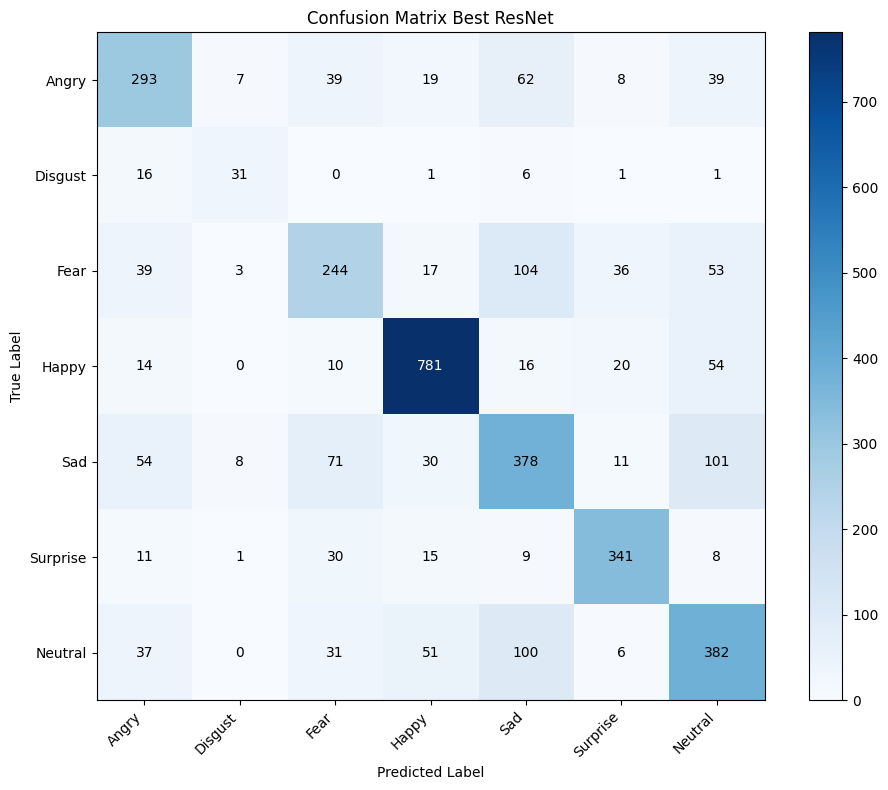

In [12]:
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

model_sgd.load_state_dict(best_model_state)
model_sgd.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model_sgd(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)
ax.set_xticks(range(7))
ax.set_yticks(range(7))
ax.set_xticklabels(emotion_labels, rotation=45, ha='right')
ax.set_yticklabels(emotion_labels)

for i in range(7):
    for j in range(7):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_title('Confusion Matrix Best ResNet')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/kaggle/working/resnet_confusion_matrix.png', dpi=150)
plt.show()

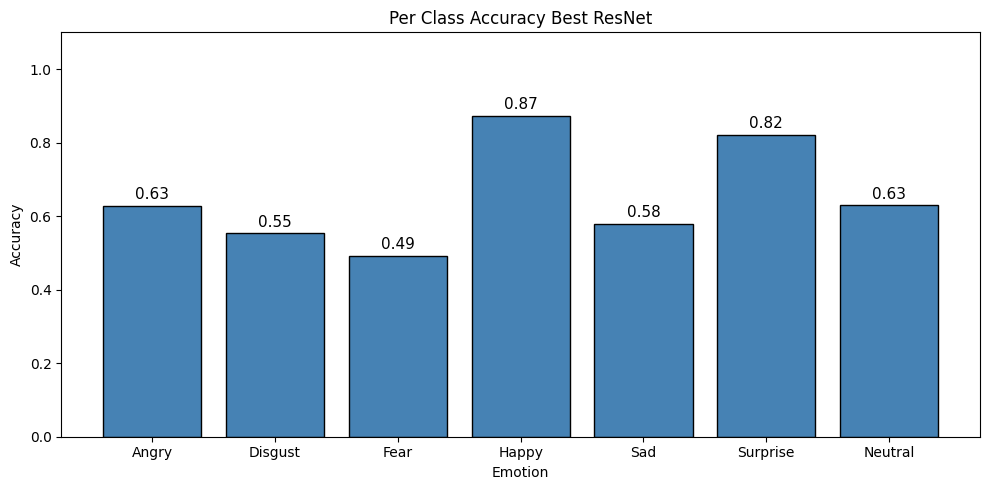

In [13]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(emotion_labels, per_class_acc, color='steelblue', edgecolor='black')

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.2f}', ha='center', va='bottom', fontsize=11)

ax.set_title('Per Class Accuracy Best ResNet')
ax.set_xlabel('Emotion')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('/kaggle/working/resnet_per_class_accuracy.png', dpi=150)
plt.show()